(python_oop)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`OOP II: ساخت کلاس‌ها <single: OOP II: Building Classes>`

```{index} single: Python; Object-Oriented Programming
```

## مرور کلی

در یک {doc}`سخنرانی قبلی <oop_intro>`، مبانی برنامه‌نویسی شیءگرا را آموختیم.

اهداف این سخنرانی عبارتند از

* پوشش OOP به صورت عمیق‌تر
* یادگیری نحوه ساخت اشیاء خودمان، متخصص‌شده برای نیازهای ما

به عنوان مثال، شما از قبل می‌دانید چگونه

* لیست‌ها، رشته‌ها و سایر اشیاء Python را ایجاد کنید
* از متدهای آنها برای تغییر محتوایشان استفاده کنید

پس حالا تصور کنید می‌خواهید برنامه‌ای بنویسید با مصرف‌کنندگانی که می‌توانند

* پول نقد نگه دارند و خرج کنند
* کالاها را مصرف کنند
* کار کنند و پول نقد به دست آورند

یک راه‌حل طبیعی در Python ایجاد مصرف‌کنندگان به عنوان اشیاء با

* داده‌ها، مانند پول نقد موجود
* متدها، مانند `buy` یا `work` که بر این داده‌ها تأثیر می‌گذارند

Python این کار را آسان می‌کند، با ارائه **تعاریف کلاس** به شما.

کلاس‌ها نقشه‌هایی هستند که به شما کمک می‌کنند اشیاء را مطابق با مشخصات خودتان بسازید.

کمی طول می‌کشد تا با سینتکس آن آشنا شوید، بنابراین مثال‌های زیادی ارائه خواهیم داد.

از import های زیر استفاده خواهیم کرد:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## مرور OOP

OOP در بسیاری از زبان‌ها پشتیبانی می‌شود:

* JAVA و Ruby نسبتاً OOP خالص هستند.
* Python هم از برنامه‌نویسی رویه‌ای و هم شیءگرا پشتیبانی می‌کند.
* Fortran و MATLAB عمدتاً رویه‌ای هستند، با مقداری OOP که اخیراً اضافه شده است.
* C یک زبان رویه‌ای است، در حالی که C++ همان C با OOP اضافه شده بر روی آن است.

بیایید مفاهیم کلی OOP را پوشش دهیم قبل از اینکه به Python تخصص یابیم.

### مفاهیم کلیدی

```{index} single: Object-Oriented Programming; Key Concepts
```

همانطور که در یک {doc}`سخنرانی قبلی <oop_intro>` بحث شد، در پارادایم OOP، داده‌ها و توابع با هم در "اشیاء" **بسته‌بندی می‌شوند**.

یک مثال لیست Python است که نه تنها داده را ذخیره می‌کند بلکه می‌داند چگونه خودش را مرتب کند و غیره.

In [2]:
x = [1, 5, 4]
x.sort()
x

[1, 4, 5]

همانطور که اکنون می‌دانیم، `sort` تابعی است که "بخشی از" شیء لیست است --- و از این رو *متد* نامیده می‌شود.

اگر می‌خواهیم انواع خودمان از اشیاء را بسازیم باید از تعاریف کلاس استفاده کنیم.

یک *تعریف کلاس* یک نقشه برای یک کلاس خاص از اشیاء است (مثلاً لیست‌ها، رشته‌ها یا اعداد مختلط).

این شرح می‌دهد

* کلاس چه نوع داده‌ای را ذخیره می‌کند
* چه متدهایی برای عمل بر روی این داده‌ها دارد

یک *شیء* یا *نمونه* تحقق کلاس است که از نقشه ایجاد شده است

* هر نمونه داده‌های منحصر به فرد خود را دارد.
* متدهای تعیین شده در تعریف کلاس بر روی این (و سایر) داده‌ها عمل می‌کنند.

در Python، داده‌ها و متدهای یک شیء در مجموع به عنوان *صفات* نامیده می‌شوند.

صفات از طریق "نمایش نقطه‌ای صفت" قابل دسترسی هستند

* `object_name.data`
* `object_name.method_name()`

در مثال

In [3]:
x = [1, 5, 4]
x.sort()
x.__class__

list

* `x` یک شیء یا نمونه است که از تعریف لیست‌های Python ایجاد شده، اما با داده‌های خاص خودش.
* `x.sort()` و `x.__class__` دو صفت از `x` هستند.
* `dir(x)` می‌تواند برای مشاهده همه صفات `x` استفاده شود.

(why_oop)=
### چرا OOP مفید است؟

OOP به همان دلیلی که انتزاع مفید است، مفید است: برای تشخیص و بهره‌برداری از ساختار مشترک.

به عنوان مثال،

* *یک زنجیره مارکوف* شامل مجموعه‌ای از حالت‌ها، یک توزیع احتمال اولیه بر روی حالت‌ها، و مجموعه‌ای از احتمالات حرکت در میان حالت‌ها است
* *یک نظریه تعادل عمومی* شامل یک فضای کالا، ترجیحات، فناوری‌ها، و یک تعریف تعادل است
* *یک بازی* شامل فهرستی از بازیکنان، فهرست‌هایی از اقدامات در دسترس هر بازیکن، بازده هر بازیکن به عنوان توابعی از اقدامات همه بازیکنان دیگر، و یک پروتکل زمان‌بندی است

اینها همه انتزاعاتی هستند که "اشیاء" از همان "نوع" را با هم جمع می‌کنند.

تشخیص ساختار مشترک به ما اجازه می‌دهد از ابزارهای مشترک استفاده کنیم.

در تئوری اقتصادی، این ممکن است یک گزاره باشد که برای همه بازی‌های یک نوع خاص اعمال می‌شود.

در Python، این ممکن است یک متد باشد که برای همه زنجیره‌های مارکوف مفید است (مثلاً `simulate`).

هنگامی که از OOP استفاده می‌کنیم، متد `simulate` به راحتی با شیء زنجیره مارکوف بسته‌بندی می‌شود.

## تعریف کلاس‌های خودتان

```{index} single: Object-Oriented Programming; Classes
```

بیایید چند کلاس ساده برای شروع بسازیم.

(oop_consumer_class)=
قبل از انجام این کار، به منظور نشان دادن قدرت کلاس‌ها، دو تابع تعریف می‌کنیم که آنها را `earn` و `spend` می‌نامیم.

In [4]:
def earn(w,y):
    "Consumer with inital wealth w earns y"
    return w+y

def spend(w,x):
    "consumer with initial wealth w spends x"
    new_wealth = w -x
    if new_wealth < 0:
        print("Insufficient funds")
    else:
        return new_wealth

تابع `earn` ثروت اولیه $w$ مصرف‌کننده را می‌گیرد و درآمد فعلی $y$ او را به آن اضافه می‌کند.

تابع `spend` ثروت اولیه $w$ مصرف‌کننده را می‌گیرد و هزینه فعلی $x$ او را از آن کم می‌کند.

می‌توانیم از این دو تابع برای پیگیری ثروت مصرف‌کننده همانطور که او درآمد کسب و خرج می‌کند استفاده کنیم.

به عنوان مثال

In [5]:
w0=100
w1=earn(w0,10)
w2=spend(w1,20)
w3=earn(w2,10)
w4=spend(w3,20)
print("w0,w1,w2,w3,w4 = ", w0,w1,w2,w3,w4)

w0,w1,w2,w3,w4 =  100 110 90 100 80


یک *کلاس* مجموعه‌ای از داده‌های مرتبط با یک *نمونه* خاص را همراه با مجموعه‌ای از توابعی که بر روی داده‌ها عمل می‌کنند، بسته‌بندی می‌کند.

در مثال ما، یک *نمونه* نام یک *شخص* خاص خواهد بود که *داده‌های نمونه* او صرفاً از ثروتش تشکیل می‌شود.

(در مثال‌های دیگر *داده‌های نمونه* از یک بردار داده تشکیل می‌شوند.)

در مثال ما، دو تابع `earn` و `spend` می‌توانند بر روی داده‌های نمونه فعلی اعمال شوند.

در مجموع، داده‌های نمونه و توابع *صفات* نامیده می‌شوند.

اینها می‌توانند به راحتی به روش‌هایی که اکنون شرح خواهیم داد قابل دسترسی باشند.

### مثال: کلاس مصرف‌کننده

ما یک کلاس `Consumer` خواهیم ساخت با

* یک صفت `wealth` که ثروت مصرف‌کننده را ذخیره می‌کند (داده)
* یک متد `earn`، جایی که `earn(y)` ثروت مصرف‌کننده را به اندازه `y` افزایش می‌دهد
* یک متد `spend`، جایی که `spend(x)` یا ثروت را به اندازه `x` کاهش می‌دهد یا در صورت عدم کفایت وجوه خطا برمی‌گرداند

اگرچه کمی مصنوعی است، این مثال از یک کلاس به ما کمک می‌کند برخی سینتکس‌های عجیب را درونی کنیم.

در اینجا نحوه تنظیم کلاس Consumer ما آمده است.

In [6]:
class Consumer:

    def __init__(self, w):
        "Initialize consumer with w dollars of wealth"
        self.wealth = w

    def earn(self, y):
        "The consumer earns y dollars"
        self.wealth += y

    def spend(self, x):
        "The consumer spends x dollars if feasible"
        new_wealth = self.wealth - x
        if new_wealth < 0:
            print("Insufficent funds")
        else:
            self.wealth = new_wealth

اینجا سینتکس خاصی وجود دارد پس بیایید با دقت طی کنیم

* کلمه کلیدی `class` نشان می‌دهد که ما در حال ساخت یک کلاس هستیم.

کلاس `Consumer` داده نمونه `wealth` و سه متد را تعریف می‌کند: `__init__`، `earn` و `spend`

* `wealth` *داده نمونه* است زیرا هر مصرف‌کننده‌ای که ایجاد می‌کنیم (هر نمونه از کلاس `Consumer`) داده‌های ثروت خاص خود را خواهد داشت.

متدهای `earn` و `spend` از توابعی که قبلاً توضیح دادیم استفاده می‌کنند و می‌توانند بالقوه بر روی داده نمونه `wealth` اعمال شوند.

متد `__init__` یک *متد سازنده* است.

هر زمان که نمونه‌ای از کلاس ایجاد کنیم، متد `__init_` به صورت خودکار فراخوانی می‌شود.

فراخوانی `__init__` یک "namespace" برای نگهداری داده‌های نمونه راه‌اندازی می‌کند --- بیشتر در این مورد بعداً.

همچنین نقش دستگاه حسابداری عجیب `self` را به تفصیل در زیر بحث خواهیم کرد.

#### استفاده

در اینجا مثالی است که در آن از کلاس `Consumer` برای ایجاد نمونه‌ای از مصرف‌کننده استفاده می‌کنیم که او را با محبت $c1$ می‌نامیم.

پس از اینکه مصرف‌کننده $c1$ را ایجاد کردیم و آن را با ثروت اولیه $10$ تجهیز کردیم، متد `spend` را اعمال خواهیم کرد.

In [7]:
c1 = Consumer(10)  # Create instance with initial wealth 10
c1.spend(5)
c1.wealth

5

In [8]:
c1.earn(15)
c1.spend(100)

Insufficent funds


البته می‌توانیم چندین نمونه، یعنی چندین مصرف‌کننده، ایجاد کنیم، هر کدام با نام و داده‌های خاص خود

In [9]:
c1 = Consumer(10)
c2 = Consumer(12)
c2.spend(4)
c2.wealth

8

In [10]:
c1.wealth

10

هر نمونه، یعنی هر مصرف‌کننده، داده‌های خود را در یک دیکشنری namespace جداگانه ذخیره می‌کند

In [11]:
c1.__dict__

{'wealth': 10}

In [12]:
c2.__dict__

{'wealth': 8}

هنگامی که به صفات دسترسی پیدا می‌کنیم یا آنها را تنظیم می‌کنیم، در واقع فقط دیکشنری نگهداری شده توسط نمونه را تغییر می‌دهیم.

#### Self

اگر دوباره به تعریف کلاس `Consumer` نگاه کنید، کلمه self را در سراسر کد خواهید دید.

قوانین استفاده از `self` در ایجاد یک کلاس این است که

* هر داده نمونه باید با `self` پیشوند بخورد
    * مثلاً متد `earn` از `self.wealth` به جای فقط `wealth` استفاده می‌کند
* متدی که در کدی که کلاس را تعریف می‌کند تعریف شده باید `self` را به عنوان اولین آرگومانش داشته باشد
    * مثلاً `def earn(self, y)` به جای فقط `def earn(y)`
* هر متدی که در کلاس ارجاع داده می‌شود باید به عنوان `self.method_name` فراخوانی شود

هیچ مثالی از قانون آخر در کد قبلی وجود ندارد اما به زودی خواهیم دید.

#### جزئیات

در این بخش، به برخی جزئیات رسمی‌تر مربوط به کلاس‌ها و `self` نگاه می‌کنیم

* ممکن است بخواهید در اولین باری که این سخنرانی را می‌خوانید به {ref}`بخش بعدی <oop_solow_growth>` بروید.
* می‌توانید پس از آشنایی با مثال‌های بیشتر به این جزئیات برگردید.

متدها در واقع در داخل یک شیء کلاس زندگی می‌کنند که هنگامی که مفسر تعریف کلاس را می‌خواند تشکیل می‌شود

In [13]:
print(Consumer.__dict__)  # Show __dict__ attribute of class object

{'__module__': '__main__', '__firstlineno__': 1, '__init__': <function Consumer.__init__ at 0x7ff4f435aca0>, 'earn': <function Consumer.earn at 0x7ff4f435ade0>, 'spend': <function Consumer.spend at 0x7ff4f435ae80>, '__static_attributes__': ('wealth',), '__dict__': <attribute '__dict__' of 'Consumer' objects>, '__weakref__': <attribute '__weakref__' of 'Consumer' objects>, '__doc__': None}


توجه کنید چگونه سه متد `__init__`، `earn` و `spend` در شیء کلاس ذخیره می‌شوند.

کد زیر را در نظر بگیرید

In [14]:
c1 = Consumer(10)
c1.earn(10)
c1.wealth

20

هنگامی که `earn` را از طریق `c1.earn(10)` فراخوانی می‌کنید، مفسر نمونه `c1` و آرگومان `10` را به `Consumer.earn` منتقل می‌کند.

در واقع، موارد زیر معادل هستند

* `c1.earn(10)`
* `Consumer.earn(c1, 10)`

در فراخوانی تابع `Consumer.earn(c1, 10)` توجه کنید که `c1` اولین آرگومان است.

به یاد بیاورید که در تعریف متد `earn`، `self` اولین پارامتر است

In [15]:
def earn(self, y):
     "The consumer earns y dollars"
     self.wealth += y

نتیجه نهایی این است که `self` در داخل فراخوانی تابع به نمونه `c1` متصل می‌شود.

به همین دلیل است که دستور `self.wealth += y` در داخل `earn` در نهایت `c1.wealth` را تغییر می‌دهد.

(oop_solow_growth)=
### مثال: مدل رشد سولو

```{index} single: Object-Oriented Programming; Methods
```

برای مثال بعدی، بیایید یک کلاس ساده برای پیاده‌سازی مدل رشد سولو بنویسیم.

مدل رشد سولو یک مدل رشد نئوکلاسیک است که در آن سهام سرمایه سرانه $k_t$ مطابق با قانون زیر تکامل می‌یابد

```{math}
:label: solow_lom

k_{t+1} = \frac{s z k_t^{\alpha} + (1 - \delta) k_t}{1 + n}
```

در اینجا

* $s$ نرخ پس‌انداز به صورت برون‌زا داده شده است
* $z$ یک پارامتر بهره‌وری است
* $\alpha$ سهم سرمایه از درآمد است
* $n$ نرخ رشد جمعیت است
* $\delta$ نرخ استهلاک است

یک **حالت پایدار** مدل یک $k$ است که {eq}`solow_lom` را حل می‌کند هنگامی که $k_{t+1} = k_t = k$.

در اینجا کلاسی است که این مدل را پیاده‌سازی می‌کند.

برخی نکات جالب در کد عبارتند از

* یک نمونه سابقه‌ای از سهام سرمایه فعلی خود را در متغیر `self.k` نگه می‌دارد.
* متد `h` سمت راست {eq}`solow_lom` را پیاده‌سازی می‌کند.
* متد `update` از `h` برای به‌روزرسانی سرمایه مطابق با {eq}`solow_lom` استفاده می‌کند.
    * توجه کنید چگونه در داخل `update` ارجاع به متد محلی `h` به صورت `self.h` است.

متدهای `steady_state` و `generate_sequence` نسبتاً خودتوضیح هستند

In [16]:
class Solow:
    r"""
    Implements the Solow growth model with the update rule

        k_{t+1} = [(s z k^α_t) + (1 - δ)k_t] /(1 + n)

    """
    def __init__(self, n=0.05,  # population growth rate
                       s=0.25,  # savings rate
                       δ=0.1,   # depreciation rate
                       α=0.3,   # share of labor
                       z=2.0,   # productivity
                       k=1.0):  # current capital stock

        self.n, self.s, self.δ, self.α, self.z = n, s, δ, α, z
        self.k = k

    def h(self):
        "Evaluate the h function"
        # Unpack parameters (get rid of self to simplify notation)
        n, s, δ, α, z = self.n, self.s, self.δ, self.α, self.z
        # Apply the update rule
        return (s * z * self.k**α + (1 - δ) * self.k) / (1 + n)

    def update(self):
        "Update the current state (i.e., the capital stock)."
        self.k =  self.h()

    def steady_state(self):
        "Compute the steady state value of capital."
        # Unpack parameters (get rid of self to simplify notation)
        n, s, δ, α, z = self.n, self.s, self.δ, self.α, self.z
        # Compute and return steady state
        return ((s * z) / (n + δ))**(1 / (1 - α))

    def generate_sequence(self, t):
        "Generate and return a time series of length t"
        path = []
        for i in range(t):
            path.append(self.k)
            self.update()
        return path

در اینجا یک برنامه کوچک است که از کلاس برای محاسبه سری‌های زمانی از دو شرط اولیه مختلف استفاده می‌کند.

حالت پایدار مشترک نیز برای مقایسه رسم شده است

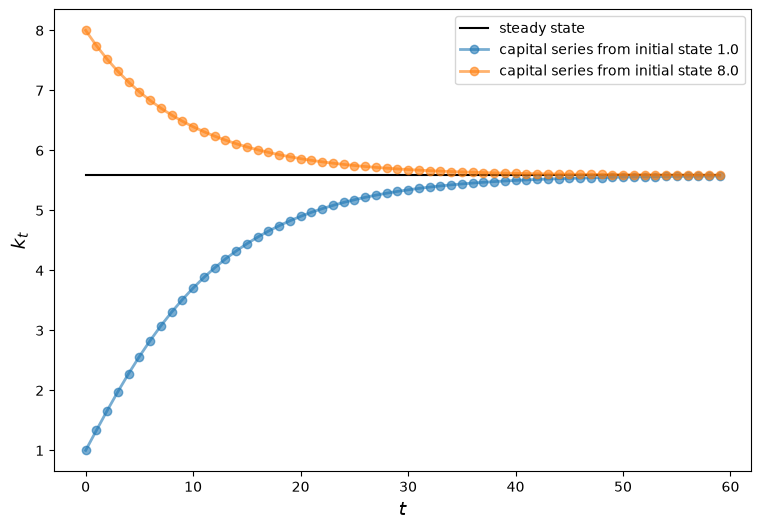

In [17]:
s1 = Solow()
s2 = Solow(k=8.0)

T = 60
fig, ax = plt.subplots(figsize=(9, 6))

# Plot the common steady state value of capital
ax.plot([s1.steady_state()]*T, 'k-', label='steady state')

# Plot time series for each economy
for s in s1, s2:
    lb = f'capital series from initial state {s.k}'
    ax.plot(s.generate_sequence(T), 'o-', lw=2, alpha=0.6, label=lb)

ax.set_xlabel('$t$', fontsize=14)
ax.set_ylabel('$k_t$', fontsize=14)
ax.legend()
plt.show()

### مثال: یک بازار

حالا، بیایید کلاسی برای بازار رقابتی بنویسیم که در آن خریداران و فروشندگان هر دو قیمت‌پذیر هستند.

بازار از اشیاء زیر تشکیل شده است:

* یک منحنی تقاضای خطی $Q = a_d - b_d p$
* یک منحنی عرضه خطی $Q = a_z + b_z (p - t)$

در اینجا

* $p$ قیمتی است که خریدار می‌پردازد، $Q$ مقدار است و $t$ مالیات به ازای هر واحد است.
* سایر نمادها پارامترهای تقاضا و عرضه هستند.

این کلاس متدهایی برای محاسبه مقادیر مختلف مورد علاقه، از جمله قیمت و مقدار تعادل رقابتی، درآمد مالیاتی جمع‌آوری شده، مازاد مصرف‌کننده و مازاد تولیدکننده ارائه می‌دهد.

در اینجا پیاده‌سازی ما آمده است.

(از تابعی از SciPy به نام quad برای انتگرال‌گیری عددی استفاده می‌کند --- موضوعی که بعداً بیشتر در مورد آن صحبت خواهیم کرد.)

In [18]:
from scipy.integrate import quad

class Market:

    def __init__(self, ad, bd, az, bz, tax):
        """
        Set up market parameters.  All parameters are scalars.  See
        https://lectures.quantecon.org/py/python_oop.html for interpretation.

        """
        self.ad, self.bd, self.az, self.bz, self.tax = ad, bd, az, bz, tax
        if ad < az:
            raise ValueError('Insufficient demand.')

    def price(self):
        "Compute equilibrium price"
        return  (self.ad - self.az + self.bz * self.tax) / (self.bd + self.bz)

    def quantity(self):
        "Compute equilibrium quantity"
        return  self.ad - self.bd * self.price()

    def consumer_surp(self):
        "Compute consumer surplus"
        # == Compute area under inverse demand function == #
        integrand = lambda x: (self.ad / self.bd) - (1 / self.bd) * x
        area, error = quad(integrand, 0, self.quantity())
        return area - self.price() * self.quantity()

    def producer_surp(self):
        "Compute producer surplus"
        #  == Compute area above inverse supply curve, excluding tax == #
        integrand = lambda x: -(self.az / self.bz) + (1 / self.bz) * x
        area, error = quad(integrand, 0, self.quantity())
        return (self.price() - self.tax) * self.quantity() - area

    def taxrev(self):
        "Compute tax revenue"
        return self.tax * self.quantity()

    def inverse_demand(self, x):
        "Compute inverse demand"
        return self.ad / self.bd - (1 / self.bd)* x

    def inverse_supply(self, x):
        "Compute inverse supply curve"
        return -(self.az / self.bz) + (1 / self.bz) * x + self.tax

    def inverse_supply_no_tax(self, x):
        "Compute inverse supply curve without tax"
        return -(self.az / self.bz) + (1 / self.bz) * x

در اینجا نمونه‌ای از استفاده آمده است

In [19]:
baseline_params = 15, .5, -2, .5, 3
m = Market(*baseline_params)
print("equilibrium price = ", m.price())

equilibrium price =  18.5


In [20]:
print("consumer surplus = ", m.consumer_surp())

consumer surplus =  33.0625


در اینجا یک برنامه کوتاه است که از این کلاس برای رسم منحنی تقاضای معکوس همراه با منحنی‌های عرضه معکوس با و بدون مالیات استفاده می‌کند

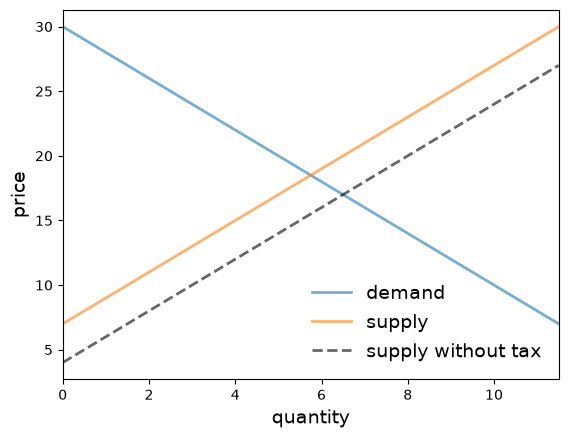

In [21]:
# Baseline ad, bd, az, bz, tax
baseline_params = 15, .5, -2, .5, 3
m = Market(*baseline_params)

q_max = m.quantity() * 2
q_grid = np.linspace(0.0, q_max, 100)
pd = m.inverse_demand(q_grid)
ps = m.inverse_supply(q_grid)
psno = m.inverse_supply_no_tax(q_grid)

fig, ax = plt.subplots()
ax.plot(q_grid, pd, lw=2, alpha=0.6, label='demand')
ax.plot(q_grid, ps, lw=2, alpha=0.6, label='supply')
ax.plot(q_grid, psno, '--k', lw=2, alpha=0.6, label='supply without tax')
ax.set_xlabel('quantity', fontsize=14)
ax.set_xlim(0, q_max)
ax.set_ylabel('price', fontsize=14)
ax.legend(loc='lower right', frameon=False, fontsize=14)
plt.show()

برنامه بعدی تابعی ارائه می‌دهد که

* یک نمونه از `Market` را به عنوان پارامتر می‌گیرد
* زیان وزن مرده ناشی از اعمال مالیات را محاسبه می‌کند

In [22]:
def deadw(m):
    "Computes deadweight loss for market m."
    # == Create analogous market with no tax == #
    m_no_tax = Market(m.ad, m.bd, m.az, m.bz, 0)
    # == Compare surplus, return difference == #
    surp1 = m_no_tax.consumer_surp() + m_no_tax.producer_surp()
    surp2 = m.consumer_surp() + m.producer_surp() + m.taxrev()
    return surp1 - surp2

در اینجا مثالی از استفاده آمده است

In [23]:
baseline_params = 15, .5, -2, .5, 3
m = Market(*baseline_params)
deadw(m)  # Show deadweight loss

1.125

### مثال: آشوب

بیایید به یک مثال دیگر نگاه کنیم، مربوط به دینامیک‌های آشوب‌ناک در سیستم‌های غیرخطی.

یک قانون انتقال ساده که می‌تواند مسیرهای زمانی نامنظم تولید کند، نگاشت لجستیک است

```{math}
:label: quadmap2

x_{t+1} = r x_t(1 - x_t) ,
\quad x_0 \in [0, 1],
\quad r \in [0, 4]
```

بیایید کلاسی برای تولید سری‌های زمانی از این مدل بنویسیم.

در اینجا یک پیاده‌سازی آمده است

In [24]:
class Chaos:
  """
  Models the dynamical system :math:`x_{t+1} = r x_t (1 - x_t)`
  """
  def __init__(self, x0, r):
      """
      Initialize with state x0 and parameter r
      """
      self.x, self.r = x0, r

  def update(self):
      "Apply the map to update state."
      self.x =  self.r * self.x *(1 - self.x)

  def generate_sequence(self, n):
      "Generate and return a sequence of length n."
      path = []
      for i in range(n):
          path.append(self.x)
          self.update()
      return path

در اینجا مثالی از استفاده آمده است

In [25]:
ch = Chaos(0.1, 4.0)     # x0 = 0.1 and r = 0.4
ch.generate_sequence(5)  # First 5 iterates

[0.1, 0.36000000000000004, 0.9216, 0.28901376000000006, 0.8219392261226498]

این قطعه کد یک مسیر طولانی‌تر را رسم می‌کند

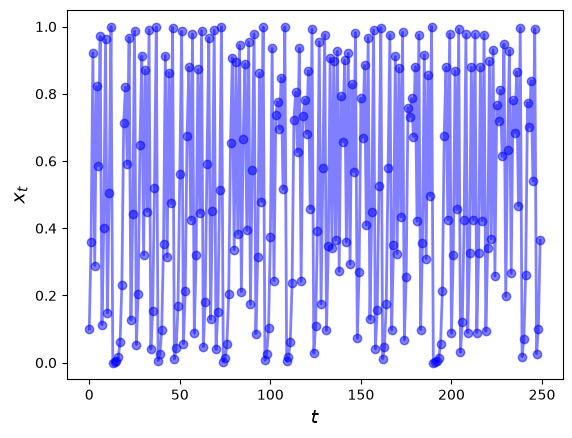

In [26]:
ch = Chaos(0.1, 4.0)
ts_length = 250

fig, ax = plt.subplots()
ax.set_xlabel('$t$', fontsize=14)
ax.set_ylabel('$x_t$', fontsize=14)
x = ch.generate_sequence(ts_length)
ax.plot(range(ts_length), x, 'bo-', alpha=0.5, lw=2, label='$x_t$')
plt.show()

قطعه کد بعدی یک نمودار انشعاب ارائه می‌دهد

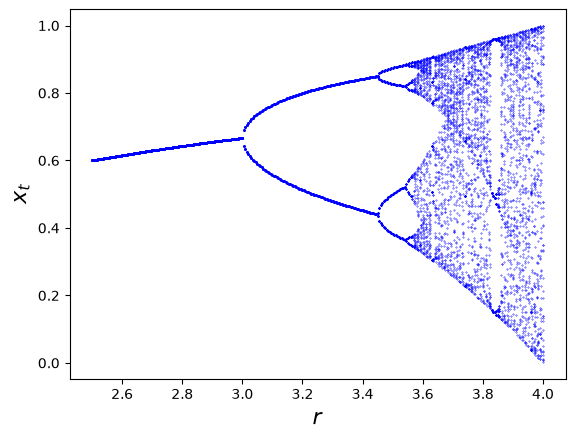

In [27]:
fig, ax = plt.subplots()
ch = Chaos(0.1, 4)
r = 2.5
while r < 4:
    ch.r = r
    t = ch.generate_sequence(1000)[950:]
    ax.plot([r] * len(t), t, 'b.', ms=0.6)
    r = r + 0.005

ax.set_xlabel('$r$', fontsize=16)
ax.set_ylabel('$x_t$', fontsize=16)
plt.show()

در محور افقی پارامتر $r$ در {eq}`quadmap2` است.

محور عمودی فضای حالت $[0, 1]$ است.

برای هر $r$ یک سری زمانی طولانی محاسبه می‌کنیم و سپس دنباله (۵۰ نقطه آخر) را رسم می‌کنیم.

دنباله سری به ما نشان می‌دهد که پس از استقرار در نوعی حالت پایدار، اگر حالت پایدار وجود داشته باشد، مسیر در کجا متمرکز می‌شود.

اینکه آیا مستقر می‌شود و ماهیت حالت پایداری که به آن مستقر می‌شود، به مقدار $r$ بستگی دارد.

برای $r$ بین حدود ۲.۵ و ۳، سری زمانی به یک نقطه ثابت که بر روی محور عمودی رسم شده است مستقر می‌شود.

برای $r$ بین حدود ۳ و ۳.۴۵، سری زمانی به نوسان بین دو مقدار رسم شده بر روی محور عمودی مستقر می‌شود.

برای $r$ کمی بالاتر از ۳.۴۵، سری زمانی به نوسان در میان چهار مقدار رسم شده بر روی محور عمودی مستقر می‌شود.

توجه کنید که هیچ مقداری از $r$ وجود ندارد که منجر به یک حالت پایدار که در میان سه مقدار نوسان می‌کند شود.

## متدهای ویژه

```{index} single: Object-Oriented Programming; Special Methods
```

Python متدهای ویژه‌ای ارائه می‌دهد که مفید هستند.

به عنوان مثال، به یاد بیاورید که لیست‌ها و تاپل‌ها مفهوم طول دارند و این طول را می‌توان از طریق تابع `len` پرس و جو کرد

In [28]:
x = (10, 20)
len(x)

2

اگر می‌خواهید مقدار بازگشتی برای تابع `len` هنگام اعمال بر روی شیء تعریف‌شده توسط کاربر خود ارائه دهید، از متد ویژه `__len__` استفاده کنید

In [29]:
class Foo:

    def __len__(self):
        return 42

حالا داریم

In [30]:
f = Foo()
len(f)

42

(call_method)=
یک متد ویژه که به طور منظم استفاده خواهیم کرد، متد `__call__` است.

این متد می‌تواند برای قابل فراخوانی کردن نمونه‌های شما، دقیقاً مانند توابع استفاده شود

In [31]:
class Foo:

    def __call__(self, x):
        return x + 42

پس از اجرا داریم

In [32]:
f = Foo()
f(8)  # Exactly equivalent to f.__call__(8)

50

تمرین ۱ یک مثال مفیدتر ارائه می‌دهد.

## تمرین‌ها

```{exercise-start}
:label: oop_ex1
```

[تابع توزیع تجمعی تجربی (ecdf)](https://en.wikipedia.org/wiki/Empirical_distribution_function) متناظر با نمونه $\{X_i\}_{i=1}^n$ به صورت زیر تعریف می‌شود

```{math}
:label: emdist

F_n(x) := \frac{1}{n}  \sum_{i=1}^n \mathbf{1}\{X_i \leq x\}
  \qquad (x \in \mathbb{R})
```

در اینجا $\mathbf{1}\{X_i \leq x\}$ یک تابع نشانگر است (یک اگر $X_i \leq x$ و صفر در غیر این صورت) و از این رو $F_n(x)$ کسری از نمونه است که زیر $x$ قرار می‌گیرد.

قضیه گلیوِنکو-کانتِلی بیان می‌کند که، به شرطی که نمونه IID باشد، ecdf $F_n$ به تابع توزیع واقعی $F$ همگرا می‌شود.

$F_n$ را به عنوان کلاسی به نام `ECDF` پیاده‌سازی کنید، که در آن

* یک نمونه داده شده $\{X_i\}_{i=1}^n$ داده‌های نمونه هستند که به عنوان `self.observations` ذخیره می‌شوند.
* کلاس یک متد `__call__` پیاده‌سازی می‌کند که $F_n(x)$ را برای هر $x$ برمی‌گرداند.

کد شما باید به صورت زیر کار کند (بدون در نظر گرفتن تصادفی بودن)

```{code-block} python3
:class: no-execute

from random import uniform

samples = [uniform(0, 1) for i in range(10)]
F = ECDF(samples)
F(0.5)  # Evaluate ecdf at x = 0.5
```

```{code-block} python3
:class: no-execute

F.observations = [uniform(0, 1) for i in range(1000)]
F(0.5)
```

به دنبال وضوح باشید، نه کارایی.

```{exercise-end}
```

```{solution-start} oop_ex1
:class: dropdown
```

In [33]:
class ECDF:

    def __init__(self, observations):
        self.observations = observations

    def __call__(self, x):
        counter = 0.0
        for obs in self.observations:
            if obs <= x:
                counter += 1
        return counter / len(self.observations)

In [34]:
# == test == #

from random import uniform

samples = [uniform(0, 1) for i in range(10)]
F = ECDF(samples)

print(F(0.5))  # Evaluate ecdf at x = 0.5

F.observations = [uniform(0, 1) for i in range(1000)]

print(F(0.5))

0.6
0.508


```{solution-end}
```


```{exercise-start}
:label: oop_ex2
```

در یک {ref}`تمرین قبلی <pyess_ex2>`، تابعی برای ارزیابی چندجمله‌ای‌ها نوشتید.

این تمرین یک پسوند است، که در آن وظیفه ساخت یک کلاس ساده به نام `Polynomial` برای نمایش و دستکاری توابع چندجمله‌ای مانند

```{math}
:label: polynom

p(x) = a_0 + a_1 x + a_2 x^2 + \cdots a_N x^N = \sum_{n=0}^N a_n x^n
    \qquad (x \in \mathbb{R})
```

داده‌های نمونه برای کلاس `Polynomial` ضرایب خواهند بود (در مورد {eq}`polynom`، اعداد $a_0, \ldots, a_N$).

متدهایی ارائه دهید که

1. چندجمله‌ای {eq}`polynom` را ارزیابی کنند و $p(x)$ را برای هر $x$ برگردانند.
1. چندجمله‌ای را مشتق بگیرند و ضرایب اصلی را با ضرایب مشتق $p'$ آن جایگزین کنند.

از استفاده از هر دستور `import` خودداری کنید.

```{exercise-end}
```

```{solution-start} oop_ex2
:class: dropdown
```

In [35]:
class Polynomial:

    def __init__(self, coefficients):
        """
        Creates an instance of the Polynomial class representing

            p(x) = a_0 x^0 + ... + a_N x^N,

        where a_i = coefficients[i].
        """
        self.coefficients = coefficients

    def __call__(self, x):
        "Evaluate the polynomial at x."
        y = 0
        for i, a in enumerate(self.coefficients):
            y += a * x**i
        return y

    def differentiate(self):
        "Reset self.coefficients to those of p' instead of p."
        new_coefficients = []
        for i, a in enumerate(self.coefficients):
            new_coefficients.append(i * a)
        # Remove the first element, which is zero
        del new_coefficients[0]
        # And reset coefficients data to new values
        self.coefficients = new_coefficients
        return new_coefficients

```{solution-end}
```